# 라이브러리 다운로드

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# CSV 파일 불러오기 및 파일 확인

In [2]:
portfolio = pd.read_csv("portfolio.csv", index_col=0)
profile = pd.read_csv("profile.csv", index_col=0)
transcript = pd.read_csv("transcript.csv", index_col=0)

## portfolio

In [3]:
portfolio

,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"['web', 'email', 'mobile', 'social']",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"['web', 'email', 'mobile', 'social']",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5


In [4]:
portfolio["offer_type"].unique()

array(['bogo', 'informational', 'discount'], dtype=object)

In [5]:
type(portfolio.loc[0, 'channels'])

str

## profile

In [6]:
profile

,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
...,...,...,...,...,...
16995,F,45,6d5f3a774f3d4714ab0c092238f3a1d7,20180604,54000.0
16996,M,61,2cb4f97358b841b9a9773a7aa05a9d77,20180713,72000.0
16997,M,49,01d26f638c274aa0b965d24cefe3183f,20170126,73000.0
16998,F,83,9dc1421481194dcd9400aec7c9ae6366,20160307,50000.0


In [7]:
profile['id'].nunique()

17000

## transcript

In [8]:
transcript

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714


In [9]:
transcript['person'].nunique()

17000

In [10]:
transcript.isna().sum()

person    0
event     0
value     0
time      0
dtype: int64

In [11]:
transcript['time'].unique()

array([  0,   6,  12,  18,  24,  30,  36,  42,  48,  54,  60,  66,  72,
        78,  84,  90,  96, 102, 108, 114, 120, 126, 132, 138, 144, 150,
       156, 162, 168, 174, 180, 186, 192, 198, 204, 210, 216, 222, 228,
       234, 240, 246, 252, 258, 264, 270, 276, 282, 288, 294, 300, 306,
       312, 318, 324, 330, 336, 342, 348, 354, 360, 366, 372, 378, 384,
       390, 396, 402, 408, 414, 420, 426, 432, 438, 444, 450, 456, 462,
       468, 474, 480, 486, 492, 498, 504, 510, 516, 522, 528, 534, 540,
       546, 552, 558, 564, 570, 576, 582, 588, 594, 600, 606, 612, 618,
       624, 630, 636, 642, 648, 654, 660, 666, 672, 678, 684, 690, 696,
       702, 708, 714], dtype=int64)

# 데이터 전처리 - 결측치 및 이상치 처리, 컬럼 분리 및 재구성

## portfolio['channels'] 분리

In [12]:
channels = ['web', 'email', 'mobile', 'social']

for ch in channels:
    portfolio[ch] = portfolio['channels'].str.contains(
        rf"'{ch}'", regex=True
    ).astype(int)

portfolio = portfolio.drop(columns=['channels'])

In [13]:
portfolio

,reward,difficulty,duration,offer_type,id,web,email,mobile,social
0,10,10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd,0,1,1,1
1,10,10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1
2,0,0,4,informational,3f207df678b143eea3cee63160fa8bed,1,1,1,0
3,5,5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,1,0
4,5,20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,1,0,0
5,3,7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,1,1,1,1
6,2,10,10,discount,fafdcd668e3743c1bb461111dcafc2a4,1,1,1,1
7,0,0,3,informational,5a8bc65990b245e5a138643cd4eb9837,0,1,1,1
8,5,5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d,1,1,1,1
9,2,10,7,discount,2906b810c7d4411798c6938adc9daaa5,1,1,1,0


## profile 결측치 및 이상치 처리

In [14]:
profile.isna().sum()

gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [15]:
df1 = profile[profile['gender'].isna()][['gender', 'age', 'income', 'id']]
df1.reset_index(drop=True)

,gender,age,income,id
0,NaN,118,NaN,68be06ca386d4c31939f3a4f0e3dd783
1,NaN,118,NaN,38fe809add3b4fcf9315a9694bb96ff5
2,NaN,118,NaN,a03223e636434f42ac4c3df47e8bac43
3,NaN,118,NaN,8ec6ce2a7e7949b1bf142def7d0e0586
4,NaN,118,NaN,68617ca6246f4fbc85e91a2a49552598
...,...,...,...,...
2170,NaN,118,NaN,5c686d09ca4d475a8f750f2ba07e0440
2171,NaN,118,NaN,d9ca82f550ac4ee58b6299cf1e5c824a
2172,NaN,118,NaN,ca45ee1883624304bac1e4c8a114f045
2173,NaN,118,NaN,a9a20fa8b5504360beb4e7c8712f8306


## transcript['event'] 분리

### offer completed 분리

In [16]:
offer_completed_df = transcript[transcript['event'] == 'offer completed']
offer_completed_df

,person,event,value,time
12658,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,0
12672,fe97aa22dd3e48c8b143116a8403dd52,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,0
12679,629fc02d56414d91bca360decdfa9288,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,0
12692,676506bad68e4161b9bbaffeb039626b,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,0
12697,8f7dd3b2afe14c078eb4f6e6fe4ba97d,offer completed,{'offer_id': '4d5c57ea9a6940dd891ad53e9dbe8da0...,0
...,...,...,...,...
306475,0c027f5f34dd4b9eba0a25785c611273,offer completed,{'offer_id': '2298d6c36e964ae4a3e7e9706d1fb8c2...,714
306497,a6f84f4e976f44508c358cc9aba6d2b3,offer completed,{'offer_id': '2298d6c36e964ae4a3e7e9706d1fb8c2...,714
306506,b895c57e8cd047a8872ce02aa54759d6,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,714
306509,8431c16f8e1d440880db371a68f82dd0,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,714


In [17]:
offer_completed_df['value'].nunique()

8

In [18]:
offer_completed_df

,person,event,value,time
12658,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,0
12672,fe97aa22dd3e48c8b143116a8403dd52,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,0
12679,629fc02d56414d91bca360decdfa9288,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,0
12692,676506bad68e4161b9bbaffeb039626b,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,0
12697,8f7dd3b2afe14c078eb4f6e6fe4ba97d,offer completed,{'offer_id': '4d5c57ea9a6940dd891ad53e9dbe8da0...,0
...,...,...,...,...
306475,0c027f5f34dd4b9eba0a25785c611273,offer completed,{'offer_id': '2298d6c36e964ae4a3e7e9706d1fb8c2...,714
306497,a6f84f4e976f44508c358cc9aba6d2b3,offer completed,{'offer_id': '2298d6c36e964ae4a3e7e9706d1fb8c2...,714
306506,b895c57e8cd047a8872ce02aa54759d6,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,714
306509,8431c16f8e1d440880db371a68f82dd0,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,714


In [19]:
transaction_df = transcript[transcript['event'] == 'transaction']
transaction_df

,person,event,value,time
12654,02c083884c7d45b39cc68e1314fec56c,transaction,{'amount': 0.8300000000000001},0
12657,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,transaction,{'amount': 34.56},0
12659,54890f68699049c2a04d415abc25e717,transaction,{'amount': 13.23},0
12670,b2f1cd155b864803ad8334cdf13c4bd2,transaction,{'amount': 19.51},0
12671,fe97aa22dd3e48c8b143116a8403dd52,transaction,{'amount': 18.97},0
...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714


### transaction 분리

In [20]:
transaction_df['value'].unique()

array(["{'amount': 0.8300000000000001}", "{'amount': 34.56}",
       "{'amount': 13.23}", ..., "{'amount': 685.07}",
       "{'amount': 405.04}", "{'amount': 476.33}"], dtype=object)

In [21]:
reward_rows = transaction_df[
    transaction_df['value'].str.contains('amount', na=False)
]

reward_rows.shape[0]

# offer completed 인 것만 reward 존재

138953

### offer received 분리

In [22]:
offer_received_df = transcript[transcript['event'] == 'offer received']
offer_received_df

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
...,...,...,...,...
257882,d087c473b4d247ccb0abfef59ba12b0e,offer received,{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'},576
257883,cb23b66c56f64b109d673d5e56574529,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},576
257884,6d5f3a774f3d4714ab0c092238f3a1d7,offer received,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},576
257885,9dc1421481194dcd9400aec7c9ae6366,offer received,{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'},576


In [23]:
offer_received_df['person'].nunique()

16994

In [24]:
offer_received_df['time'].nunique()

6

In [25]:
offer_received_df['time'].unique()

array([  0, 168, 336, 408, 504, 576], dtype=int64)

In [26]:
offer_received_df['time'].value_counts().sort_index()

time
0      12650
168    12669
336    12711
408    12778
504    12704
576    12765
Name: count, dtype: int64

In [27]:
offer_received_df.groupby('time')['person'].nunique()

time
0      12650
168    12669
336    12711
408    12778
504    12704
576    12765
Name: person, dtype: int64

### 분리한 컬럼 재결합

In [28]:
import ast

transcript['value'] = transcript['value'].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else x
)

In [29]:
def parse_value(row):
    val = row['value']
    event = row['event']

    offer_id = None
    amount = None
    reward = None

    if event in ['offer received', 'offer viewed']:
        offer_id = val.get('offer id')

    elif event == 'transaction':
        amount = val.get('amount')

    elif event == 'offer completed':
        # offer id / offer_id 둘 다 대응
        offer_id = val.get('offer_id') or val.get('offer id')
        reward = val.get('reward')

    return pd.Series({
        'offer_id': offer_id,
        'amount': amount,
        'reward': reward
    })


transcript_parsed = pd.concat(
    [transcript.drop(columns=['value']),
     transcript.apply(parse_value, axis=1)],
    axis=1
)

transcript_parsed

,person,event,time,offer_id,amount,reward
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN
...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,714,NaN,1.59,NaN
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,NaN,9.53,NaN
306531,a00058cf10334a308c68e7631c529907,transaction,714,NaN,3.61,NaN
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,714,NaN,3.53,NaN


In [30]:
transcript_parsed = transcript_parsed[
    ['person', 'event', 'offer_id', 'amount', 'reward', 'time']
]
transcript_parsed

,person,event,offer_id,amount,reward,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0
...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,NaN,1.59,NaN,714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,NaN,9.53,NaN,714
306531,a00058cf10334a308c68e7631c529907,transaction,NaN,3.61,NaN,714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,NaN,3.53,NaN,714


### 결합 확인

In [31]:
transcript_parsed['event'].unique()

array(['offer received', 'offer viewed', 'transaction', 'offer completed'],
      dtype=object)

In [32]:
transcript_parsed.loc[transcript_parsed['event'] == 'offer received', 'offer_id'].isna().sum()


0

In [33]:
transcript_parsed.loc[transcript_parsed['event'] == 'offer viewed', 'offer_id'].isna().sum()


0

In [34]:
transcript_parsed.loc[transcript_parsed['event'] == 'offer completed', 'offer_id'].isna().sum()

0

In [35]:
transcript_parsed.loc[transcript_parsed['event'] == 'offer completed', 'reward'].isna().sum()

0

In [36]:
transcript_parsed.to_csv(
    "transcript_parsed.csv",
    index=False,
    encoding="utf-8-sig"
)

In [37]:
transcript_parsed['reward'].unique()

array([nan,  2.,  5., 10.,  3.])

# 기초 EDA

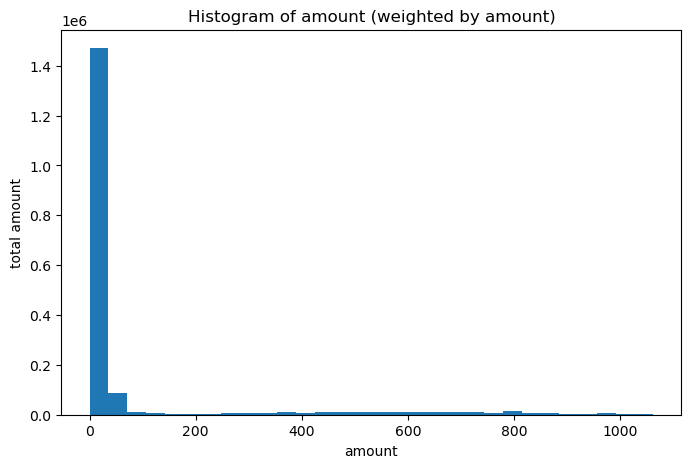

In [38]:
import matplotlib.pyplot as plt
import numpy as np

values = transcript_parsed['amount'].dropna()

plt.figure(figsize=(8,5))
plt.hist(
    values,
    bins=30,
    weights=values
)

plt.xlabel('amount')
plt.ylabel('total amount')
plt.title('Histogram of amount (weighted by amount)')
plt.show()

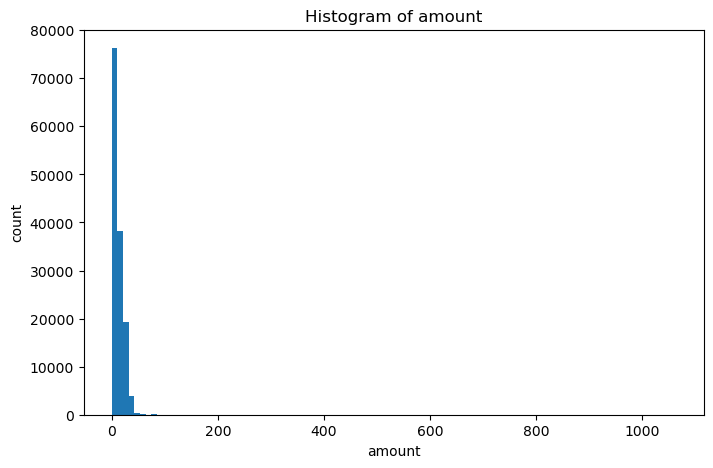

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(transcript_parsed['amount'], bins=100)
plt.xlabel('amount')
plt.ylabel('count')
plt.title('Histogram of amount')
plt.show()


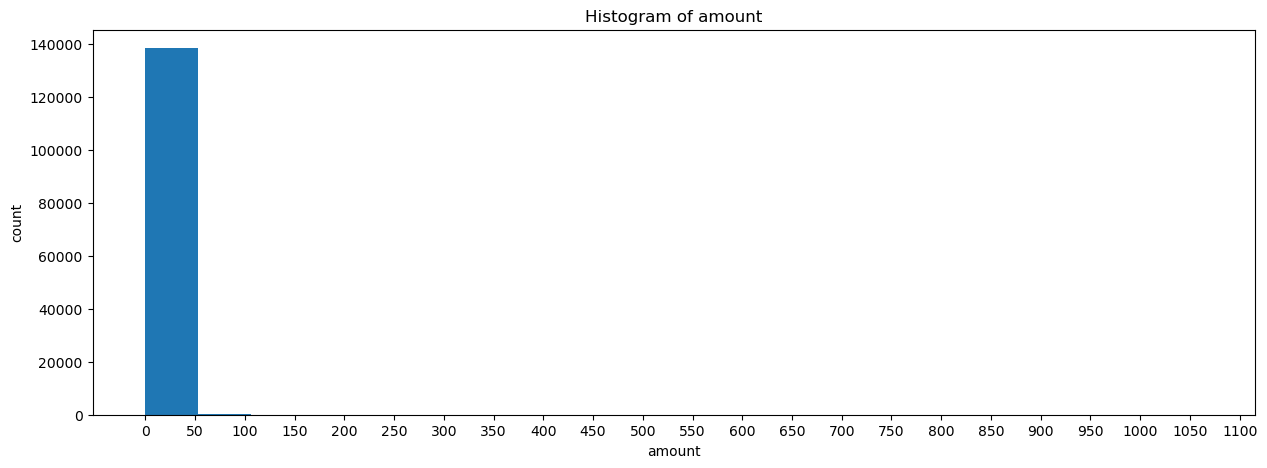

In [40]:
import numpy as np
import matplotlib.pyplot as plt

values = transcript_parsed['amount'].dropna()

plt.figure(figsize=(15,5))
plt.hist(values, bins=20)
plt.xlabel('amount')
plt.ylabel('count')
plt.title('Histogram of amount')

# x축 눈금 50 단위
plt.xticks(np.arange(0, values.max() + 50, 50))

plt.show()


In [41]:
import numpy as np
import pandas as pd

values = transcript_parsed['amount'].dropna()

bins = np.arange(0, values.max() + 50, 50)

hist, bin_edges = np.histogram(values, bins=bins)

amount_table = pd.DataFrame({
    'amount_range': [
        f"{int(bin_edges[i])}–{int(bin_edges[i+1])}"
        for i in range(len(hist))
    ],
    'count': hist
})

amount_table


,amount_range,count
0,0–50,138247
1,50–100,228
2,100–150,93
3,150–200,14
4,200–250,22
5,250–300,32
6,300–350,29
7,350–400,41
8,400–450,29
9,450–500,33


## Quantile

In [42]:
LOW_Q = 0.001   # 하위 0.1%
HIGH_Q = 0.999  # 상위 99.9%

In [43]:
low_thr = transcript_parsed['amount'].quantile(LOW_Q)
high_thr = transcript_parsed['amount'].quantile(HIGH_Q)

low_thr, high_thr

(0.05, 576.5626400000066)

In [44]:
amount_outlier_mask = (
    (transcript_parsed['amount'] <= low_thr) |
    (transcript_parsed['amount'] >= high_thr)
)


In [45]:
outlier_count = amount_outlier_mask.sum()
total_count = len(transcript_parsed)

outlier_count, outlier_count / total_count


(570, 0.001859500088081583)

In [46]:
transcript_parsed.loc[
    transcript_parsed['amount'] <= low_thr,
    'amount'
].sort_values().head(10)

12967     0.05
228597    0.05
227660    0.05
227608    0.05
227182    0.05
227086    0.05
226635    0.05
226416    0.05
226019    0.05
225538    0.05
Name: amount, dtype: float64

In [47]:
transcript_parsed.loc[
    transcript_parsed['amount'] >= high_thr,
    'amount'
].sort_values(ascending=False).head(10)


284273    1062.28
301790    1015.73
42253     1001.85
140346     989.34
302951     977.78
294112     966.24
21490      962.10
280015     961.21
280202     957.15
27692      947.43
Name: amount, dtype: float64

In [48]:
transcript_parsed['amount'].quantile(
    [0, 0.001, 0.005, 0.01, 0.5, 0.99, 0.995, 0.999, 1.0]
)

0.000       0.05000
0.001       0.05000
0.005       0.08000
0.010       0.15000
0.500       8.89000
0.990      40.01960
0.995      50.41240
0.999     576.56264
1.000    1062.28000
Name: amount, dtype: float64

In [49]:
quantiles = [
    0,
    0.0001, 0.0005, 0.001, 0.002, 0.005,
    0.01, 0.02, 0.05,
    0.1, 0.25, 0.5,
    0.75, 0.9, 0.95, 0.98,
    0.99, 0.995, 0.998, 0.999, 0.9995, 0.9999,
    1.0
]

quantile_table = (
    transcript_parsed['amount']
    .quantile(quantiles)
    .reset_index()
)

quantile_table.columns = ['quantile', 'amount']
quantile_table

,quantile,amount
0,0.0000,0.050000
1,0.0001,0.050000
2,0.0005,0.050000
3,0.0010,0.050000
4,0.0020,0.050000
5,0.0050,0.080000
6,0.0100,0.150000
7,0.0200,0.280000
8,0.0500,0.590000
9,0.1000,1.080000


## Zscore

In [50]:
from sklearn.preprocessing import StandardScaler

zscore_df = transcript_parsed[['amount']]
scale_df = StandardScaler().fit_transform(zscore_df)

merge_df = pd.concat([zscore_df, pd.DataFrame(scale_df)], axis=1)
merge_df.columns = ['amount', 'zscore']

# Z-Score 기반, -3 보다 작거나 또는 3보다 큰 경우를 이상치로 판별
mask = ((merge_df['zscore']<-3) | (merge_df['zscore']>3))
strange_df = merge_df[mask]
strange_df

,amount,zscore
15540,195.24,6.031739
18053,448.97,14.419391
18417,219.02,6.817844
18800,628.41,20.351210
19097,871.51,28.387462
...,...,...
304828,120.29,3.554088
305143,290.93,9.195001
305567,685.07,22.224242
305925,405.04,12.967180


In [51]:
merge_df

,amount,zscore
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
306529,1.59,-0.369825
306530,9.53,-0.107349
306531,3.61,-0.303049
306532,3.53,-0.305693


In [52]:
strange_df.count()

amount    468
zscore    468
dtype: int64

In [53]:
strange_df.to_csv(
    'strange_df.csv',
    index=False,
    encoding='utf-8-sig'
)


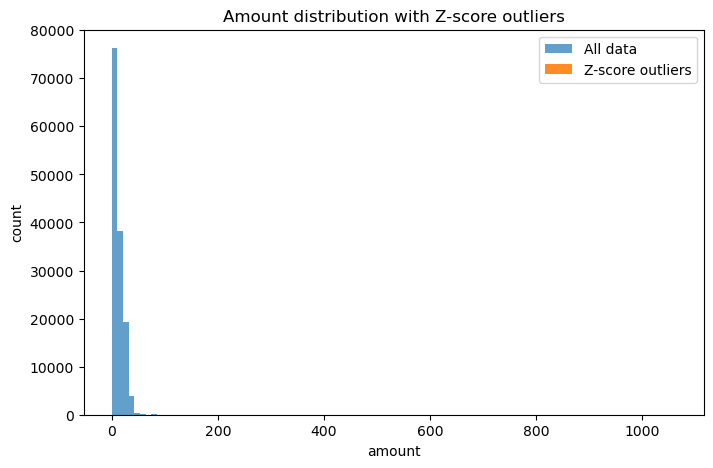

In [54]:
import matplotlib.pyplot as plt

values = merge_df['amount']
outliers = strange_df['amount']

plt.figure(figsize=(8,5))

# 전체 분포
plt.hist(values, bins=100, alpha=0.7, label='All data')

# 이상치만 덮어그리기
plt.hist(outliers, bins=100, alpha=0.9, label='Z-score outliers')

plt.xlabel('amount')
plt.ylabel('count')
plt.title('Amount distribution with Z-score outliers')
plt.legend()
plt.show()

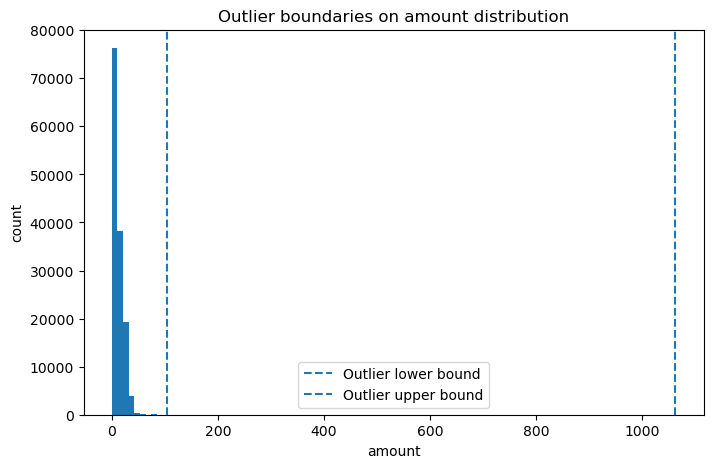

In [55]:
upper = outliers.min()
lower = outliers.max()

plt.figure(figsize=(8,5))
plt.hist(values, bins=100)

plt.axvline(upper, linestyle='--', label='Outlier lower bound')
plt.axvline(lower, linestyle='--', label='Outlier upper bound')

plt.xlabel('amount')
plt.ylabel('count')
plt.title('Outlier boundaries on amount distribution')
plt.legend()
plt.show()


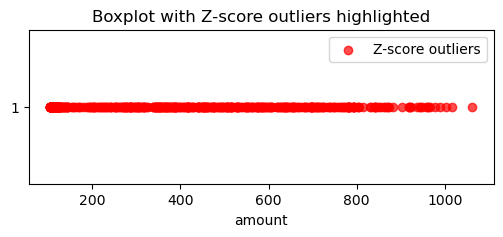

In [56]:
import matplotlib.pyplot as plt

values = merge_df['amount']
outliers = strange_df['amount']

plt.figure(figsize=(6,2))

# 전체 분포 박스플롯
plt.boxplot(values, vert=False)

# 이상치 점을 다른 색으로 표시
plt.scatter(
    outliers,
    [1] * len(outliers),
    color='red',     
    alpha=0.7,
    label='Z-score outliers'
)

plt.xlabel('amount')
plt.title('Boxplot with Z-score outliers highlighted')
plt.legend()
plt.show()


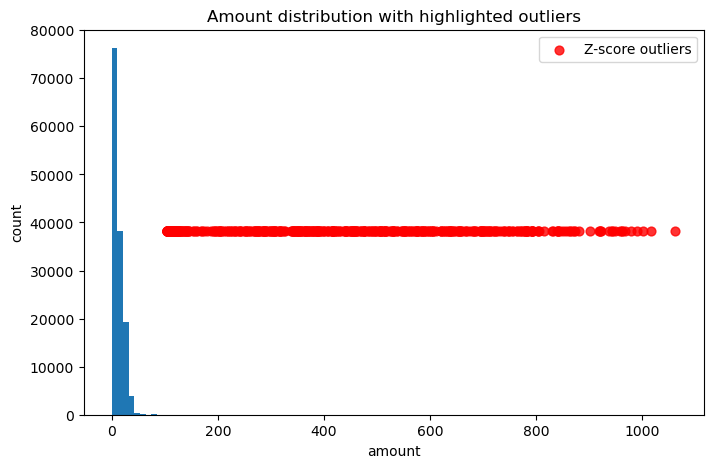

In [57]:
import matplotlib.pyplot as plt
import numpy as np

values = merge_df['amount']
outliers = strange_df['amount']

plt.figure(figsize=(8,5))

counts, bins, _ = plt.hist(values, bins=100)

# 히스토그램 최대 높이의 중간쯤
y_level = counts.max() * 0.5

plt.scatter(
    outliers,
    np.full(len(outliers), y_level),
    color='red',
    s=40,
    alpha=0.8,
    label='Z-score outliers'
)

plt.xlabel('amount')
plt.ylabel('count')
plt.title('Amount distribution with highlighted outliers')
plt.legend()
plt.show()


## IQR 박스플롯

In [58]:
q3 = transcript_parsed['amount'].quantile(0.75) 
q1 = transcript_parsed['amount'].quantile(0.25)

iqr = q3 - q1

def is_outlier(transcript_parsed):
    score = transcript_parsed['amount']
    if score > q3 + (1.5 * iqr) or score < q1 - (1.5 * iqr):
        return '이상치'
    else:
        return '이상치아님'
    

transcript_parsed['이상치여부'] = transcript_parsed.apply(is_outlier, axis = 1) 
transcript_parsed

C:\Users\heoxx\AppData\Local\Temp\ipykernel_29148\4127373074.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transcript_parsed['이상치여부'] = transcript_parsed.apply(is_outlier, axis = 1)


,person,event,offer_id,amount,reward,time,이상치여부
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,0,이상치아님
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,0,이상치아님
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,0,이상치아님
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,0,이상치아님
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0,이상치아님
...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,NaN,1.59,NaN,714,이상치아님
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,NaN,9.53,NaN,714,이상치아님
306531,a00058cf10334a308c68e7631c529907,transaction,NaN,3.61,NaN,714,이상치아님
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,NaN,3.53,NaN,714,이상치아님


In [59]:
transcript_parsed.groupby('이상치여부').count()

,person,event,offer_id,amount,reward,time
이상치여부,,,,,,
이상치,1236,1236,0,1236,0,1236
이상치아님,305298,305298,167581,137717,33579,305298


## Zscore 선정

In [60]:
strange_persons = transcript_parsed.loc[strange_df.index, 'person'].unique()

In [61]:
strange_person_history = transcript_parsed[
    transcript_parsed['person'].isin(strange_persons)
].sort_values(['person', 'time'])

In [62]:
strange_person_history

,person,event,offer_id,amount,reward,time,이상치여부
8117,00e20b4ca129458aaab0f4727ef3513a,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0,이상치아님
27238,00e20b4ca129458aaab0f4727ef3513a,offer viewed,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,36,이상치아님
27239,00e20b4ca129458aaab0f4727ef3513a,transaction,NaN,6.24,NaN,36,이상치아님
41592,00e20b4ca129458aaab0f4727ef3513a,transaction,NaN,2.04,NaN,96,이상치아님
71131,00e20b4ca129458aaab0f4727ef3513a,transaction,NaN,4.61,NaN,174,이상치아님
...,...,...,...,...,...,...,...
228643,fff3ba4757bd42088c044ca26d73817a,offer completed,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,528,이상치아님
233587,fff3ba4757bd42088c044ca26d73817a,offer viewed,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,540,이상치아님
233588,fff3ba4757bd42088c044ca26d73817a,transaction,NaN,388.22,NaN,540,이상치
237974,fff3ba4757bd42088c044ca26d73817a,transaction,NaN,26.09,NaN,552,이상치아님


In [63]:
strange_person_history.to_csv(
    'strange_person_history.csv',
    index=False,
    encoding='utf-8-sig'
)


In [64]:
# 이상치 amount 행
outlier_rows = transcript_parsed.loc[mask, ['person', 'time']]

# 사람+시간 조합
outlier_person_time = outlier_rows.apply(tuple, axis=1).tolist()


In [65]:
# 조건: (person, time) 쌍이 이상치와 동일 AND event == 'offer completed'
remove_mask = transcript_parsed.apply(
    lambda row: (row['person'], row['time']) in outlier_person_time
                and row['event'] == 'offer completed',
    axis=1
)

# 클린 데이터 생성
transcript_clean = transcript_parsed[~remove_mask].copy()


In [66]:
before_completed = (transcript_parsed['event'] == 'offer completed').sum()
after_completed = (transcript_clean['event'] == 'offer completed').sum()

print(f"제거된 offer completed 수: {before_completed - after_completed}")
print(f"제거 비율: {(before_completed - after_completed)/before_completed:.4%}")

제거된 offer completed 수: 242
제거 비율: 0.7207%


### 제거 확인

In [67]:
transcript_clean

,person,event,offer_id,amount,reward,time,이상치여부
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,0,이상치아님
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,0,이상치아님
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,0,이상치아님
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,0,이상치아님
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0,이상치아님
...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,NaN,1.59,NaN,714,이상치아님
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,NaN,9.53,NaN,714,이상치아님
306531,a00058cf10334a308c68e7631c529907,transaction,NaN,3.61,NaN,714,이상치아님
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,NaN,3.53,NaN,714,이상치아님


In [68]:
# 원본 데이터에 동일한 mask 적용
transcript_clean = transcript_clean.loc[~mask].copy()
transcript_clean

,person,event,offer_id,amount,reward,time,이상치여부
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,0,이상치아님
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,0,이상치아님
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,0,이상치아님
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,0,이상치아님
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0,이상치아님
...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,NaN,1.59,NaN,714,이상치아님
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,NaN,9.53,NaN,714,이상치아님
306531,a00058cf10334a308c68e7631c529907,transaction,NaN,3.61,NaN,714,이상치아님
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,NaN,3.53,NaN,714,이상치아님


In [69]:
before_total = len(transcript_parsed)
after_total = len(transcript_clean)

before_total, after_total

(306534, 305824)

In [70]:
transcript_clean

,person,event,offer_id,amount,reward,time,이상치여부
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,0,이상치아님
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,0,이상치아님
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,0,이상치아님
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,0,이상치아님
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0,이상치아님
...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,NaN,1.59,NaN,714,이상치아님
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,NaN,9.53,NaN,714,이상치아님
306531,a00058cf10334a308c68e7631c529907,transaction,NaN,3.61,NaN,714,이상치아님
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,NaN,3.53,NaN,714,이상치아님


In [71]:
transcript_clean = transcript_clean.drop(columns=['이상치여부'])

In [72]:
transcript_clean['amount'] = transcript_clean['amount'].round(2)

In [73]:
transcript_clean = transcript_clean.rename(
    columns={'person': 'customer_id'}
)

In [74]:
transcript_clean

,customer_id,event,offer_id,amount,reward,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0
...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,NaN,1.59,NaN,714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,NaN,9.53,NaN,714
306531,a00058cf10334a308c68e7631c529907,transaction,NaN,3.61,NaN,714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,NaN,3.53,NaN,714


# CSV 파일로 변환

## transcript

In [75]:
transcript_clean.to_csv(
    'transcript_clean.csv',
    index=False,
    encoding='utf-8-sig'
)

## portfolio

In [76]:
portfolio_clean = portfolio.copy()

In [77]:
portfolio_clean

,reward,difficulty,duration,offer_type,id,web,email,mobile,social
0,10,10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd,0,1,1,1
1,10,10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1
2,0,0,4,informational,3f207df678b143eea3cee63160fa8bed,1,1,1,0
3,5,5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,1,0
4,5,20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,1,0,0
5,3,7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,1,1,1,1
6,2,10,10,discount,fafdcd668e3743c1bb461111dcafc2a4,1,1,1,1
7,0,0,3,informational,5a8bc65990b245e5a138643cd4eb9837,0,1,1,1
8,5,5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d,1,1,1,1
9,2,10,7,discount,2906b810c7d4411798c6938adc9daaa5,1,1,1,0


In [78]:
portfolio_clean.to_csv(
    'portfolio_clean.csv',
    index=False,
    encoding='utf-8-sig'
)

## profile

In [79]:
profile

,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
...,...,...,...,...,...
16995,F,45,6d5f3a774f3d4714ab0c092238f3a1d7,20180604,54000.0
16996,M,61,2cb4f97358b841b9a9773a7aa05a9d77,20180713,72000.0
16997,M,49,01d26f638c274aa0b965d24cefe3183f,20170126,73000.0
16998,F,83,9dc1421481194dcd9400aec7c9ae6366,20160307,50000.0


## 데이터 최종 결합

In [80]:
transcript_clean

,customer_id,event,offer_id,amount,reward,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0
...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,NaN,1.59,NaN,714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,NaN,9.53,NaN,714
306531,a00058cf10334a308c68e7631c529907,transaction,NaN,3.61,NaN,714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,NaN,3.53,NaN,714


In [81]:
# transcript_clean ⟵ profile (customer_id = id)
merged_df = transcript_clean.merge(
    profile,
    how='left',
    left_on='customer_id',
    right_on='id'
)

# profile 쪽 id 컬럼 정리
merged_df = merged_df.drop(columns=['id'])

# merged_df ⟵ portfolio_clean (offer_id = id)
merged_df = merged_df.merge(
    portfolio_clean,
    how='left',
    left_on='offer_id',
    right_on='id'
)

# portfolio 쪽 id 컬럼 정리
merged_df = merged_df.drop(columns=['id'])


In [82]:
merged_df

,customer_id,event,offer_id,amount,reward_x,time,gender,age,became_member_on,income,reward_y,difficulty,duration,offer_type,web,email,mobile,social
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,0,F,75,20170509,100000.0,5.0,5.0,7.0,bogo,1.0,1.0,1.0,0.0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,0,NaN,118,20170804,NaN,5.0,20.0,10.0,discount,1.0,1.0,0.0,0.0
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,0,M,68,20180426,70000.0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,0,NaN,118,20170925,NaN,2.0,10.0,10.0,discount,1.0,1.0,1.0,1.0
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0,NaN,118,20171002,NaN,10.0,10.0,5.0,bogo,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305819,b3a1272bc9904337b331bf348c3e8c17,transaction,NaN,1.59,NaN,714,M,66,20180101,47000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305820,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,NaN,9.53,NaN,714,M,52,20180408,62000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305821,a00058cf10334a308c68e7631c529907,transaction,NaN,3.61,NaN,714,F,63,20130922,52000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305822,76ddbd6576844afe811f1a3c0fbb5bec,transaction,NaN,3.53,NaN,714,M,57,20160709,40000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
merged_df = merged_df.rename(columns={'reward_x': 'reward'})
merged_df = merged_df.rename(columns={'reward_y': 'reward_promise'})

In [84]:
merged_df

,customer_id,event,offer_id,amount,reward,time,gender,age,became_member_on,income,reward_promise,difficulty,duration,offer_type,web,email,mobile,social
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,0,F,75,20170509,100000.0,5.0,5.0,7.0,bogo,1.0,1.0,1.0,0.0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,0,NaN,118,20170804,NaN,5.0,20.0,10.0,discount,1.0,1.0,0.0,0.0
2,e2127556f4f64592b11af22de27a7932,offer received,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,0,M,68,20180426,70000.0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,0,NaN,118,20170925,NaN,2.0,10.0,10.0,discount,1.0,1.0,1.0,1.0
4,68617ca6246f4fbc85e91a2a49552598,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0,NaN,118,20171002,NaN,10.0,10.0,5.0,bogo,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305819,b3a1272bc9904337b331bf348c3e8c17,transaction,NaN,1.59,NaN,714,M,66,20180101,47000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305820,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,NaN,9.53,NaN,714,M,52,20180408,62000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305821,a00058cf10334a308c68e7631c529907,transaction,NaN,3.61,NaN,714,F,63,20130922,52000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
305822,76ddbd6576844afe811f1a3c0fbb5bec,transaction,NaN,3.53,NaN,714,M,57,20160709,40000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
merged_df.to_csv(
    'starbucks_join.csv',
    index=False,
    encoding='utf-8-sig'
)

In [86]:
merged_df['age'].unique()

array([ 75, 118,  68,  65,  58,  61,  62,  64,  78,  88,  42,  56,  59,
        22,  96,  40,  69,  26,  20,  45,  54,  39,  79,  66,  48,  37,
        73,  44,  63,  27,  67,  76,  53,  74,  38,  70,  49,  50,  90,
        19,  72,  52,  55,  57,  18,  51,  71,  83,  29,  25,  77,  47,
        60,  36,  46,  81,  24,  34,  89,  41,  30,  32,  85,  23, 100,
        43,  82,  28,  35,  80,  84,  87,  86,  94,  33,  95,  31,  93,
        92,  21,  98,  91, 101,  97,  99], dtype=int64)